# Mesoscale mouse connectivity and the cortico-thalamic hierarchy

This loads two related datasets:

- `mesoscale.load()`: the Oh et al. (2014) / Knox et al. (2018) regularized-regression mesoscale connectivity matrix, regionalized onto 291 Allen summary structures, with per-structure volumes attached so it can be reaggregated onto any coarser parcellation.
- `mesoscale.load_hierarchy()`: the Harris et al. (2019) precomputed cortico-thalamic hierarchy scores for 61 cortical and thalamic areas.

References:

1. S. W. Oh et al., "A mesoscale connectome of the mouse brain," *Nature*, 508, 207-214 (2014). doi: 10.1038/nature13186
2. J. E. Knox et al., "High-resolution data-driven model of the mouse connectome," *Network Neuroscience*, 3, 217-236 (2018). doi: 10.1162/netn_a_00066
3. J. A. Harris et al., "Hierarchical organization of cortical and thalamic connectivity," *Nature*, 575, 195-202 (2019). doi: 10.1038/s41586-019-1716-z


In [1]:
%matplotlib inline

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from iblatlas.connectivity import mesoscale
from iblatlas.regions import BrainRegions

sns.set_theme(context='notebook')

connectivity = mesoscale.load()
hierarchy = mesoscale.load_hierarchy()
connectivity.head()

,source_structure_id,hemisphere,target_structure_id,value,metric,source_acronym,target_acronym,source_volume_mm3,target_volume_mm3
0,184,contra,1,0.519956,connection_strength,FRP,TMv,0.243055,0.027055
1,184,contra,100,0.611588,connection_strength,FRP,IPN,0.243055,0.082914
2,184,contra,1002,1.169252,connection_strength,FRP,AUDp,0.243055,0.537547
3,184,contra,1004,0.213878,connection_strength,FRP,PMv,0.243055,0.048922
4,184,contra,1007,0.788386,connection_strength,FRP,SIM,0.243055,1.424016


## Connectivity heatmap

Ipsilateral `connection_strength`, restricted to the cortical and thalamic areas covered by the hierarchy table, ordered by the Allen CCF ontology order, with tick labels coloured by Allen CCF region colour.

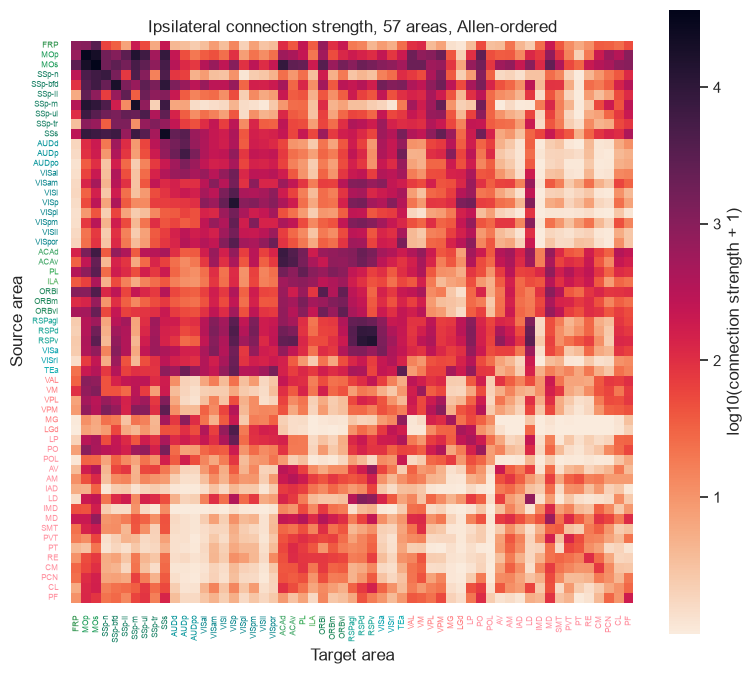

In [2]:
br = BrainRegions()

areas = hierarchy['area'].unique()
ipsi_strength = connectivity[
    (connectivity['metric'] == 'connection_strength')
    & (connectivity['hemisphere'] == 'ipsi')
    & connectivity['source_acronym'].isin(areas)
    & connectivity['target_acronym'].isin(areas)
]
matrix = ipsi_strength.pivot(index='source_acronym', columns='target_acronym', values='value')
common = matrix.index.intersection(matrix.columns)
matrix = matrix.loc[common, common]

order = dict(zip(*[br.get(br.acronym2id(matrix.index.to_numpy()))[k] for k in ('acronym', 'order')]))
ordered_areas = sorted(matrix.index, key=lambda a: order[a])
matrix = matrix.loc[ordered_areas, ordered_areas]

info = br.get(br.acronym2id(np.array(ordered_areas)))
hexcolors = dict(zip(info.acronym, (f'#{r:02x}{g:02x}{b:02x}' for r, g, b in info.rgb)))

fig, ax = plt.subplots(figsize=(8, 7))
sns.heatmap(np.log10(matrix.to_numpy(dtype=float) + 1), xticklabels=ordered_areas, yticklabels=ordered_areas,
            cmap='rocket_r', square=True, cbar_kws={'label': 'log10(connection strength + 1)'}, ax=ax)
ax.set_xlabel('Target area')
ax.set_ylabel('Source area')
ax.set_title(f'Ipsilateral connection strength, {len(ordered_areas)} areas, Allen-ordered')
for tick_label in list(ax.get_xticklabels()) + list(ax.get_yticklabels()):
    tick_label.set_color(hexcolors[tick_label.get_text()])
    tick_label.set_fontsize(6)
fig.tight_layout()

## Reaggregating onto a coarser parcellation

`connection_strength` is additive: summing it within groups on both the source and target side gives the exact value for a coarser parcellation, as long as that parcellation partitions the 291 summary structures with no overlap or gaps -- true of any Allen ontology grouping. Here we reaggregate onto the 10 Cosmos regions and plot the result, ordered and coloured by their Allen CCF region colour.

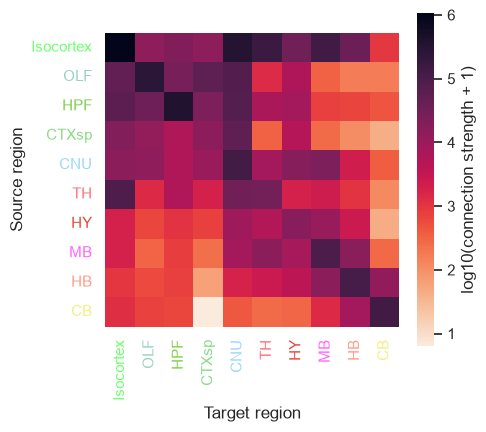

In [3]:
strength = connectivity[connectivity['metric'] == 'connection_strength'].copy()
strength['source_cosmos'] = br.id2acronym(br.id2id(strength['source_structure_id'].to_numpy(), mapping='Cosmos'))
strength['target_cosmos'] = br.id2acronym(br.id2id(strength['target_structure_id'].to_numpy(), mapping='Cosmos'))

cosmos = (
    strength[strength['hemisphere'] == 'ipsi']
    .groupby(['source_cosmos', 'target_cosmos'])['value'].sum()
    .reset_index()
    .pivot(index='source_cosmos', columns='target_cosmos', values='value')
)

order = dict(zip(*[br.get(br.acronym2id(cosmos.index.to_numpy()))[k] for k in ('acronym', 'order')]))
ordered = sorted(cosmos.index, key=lambda a: order[a])
cosmos = cosmos.loc[ordered, ordered]

info = br.get(br.acronym2id(np.array(ordered)))
hexcolors = dict(zip(info.acronym, (f'#{r:02x}{g:02x}{b:02x}' for r, g, b in info.rgb)))

fig, ax = plt.subplots(figsize=(5, 4.5))
sns.heatmap(np.log10(cosmos.to_numpy(dtype=float) + 1), xticklabels=ordered, yticklabels=ordered,
            cmap='rocket_r', square=True, cbar_kws={'label': 'log10(connection strength + 1)'}, ax=ax)
ax.set_xlabel('Target region')
ax.set_ylabel('Source region')
for tick_label in list(ax.get_xticklabels()) + list(ax.get_yticklabels()):
    tick_label.set_color(hexcolors[tick_label.get_text()])
fig.tight_layout()